# Indirect Two-Tank Sensible Thermal Energy Storage (TES) Model

## Overview
This notebook translates the mathematical parameters for the liquid thermal oil storage system from Engineering Equation Solver (EES) into a transient Python module. 

The framework models an indirect two-tank sensible heat storage circuit using **Therminol VP-1** as the working thermal medium. It tracks real-time internal tank fluid temperatures, charging/discharging rates, parasitic ambient heat losses, and the system's net state-of-charge (SoC) over a continuous diurnal cycle.

---

## 🔬 Scholarly Reference
The storage boundaries and thermodynamic fluid limits match the definitions used in:
* **Boodaghi, H.**, et al. (2023). *"Design and Performance Assessment of a Novel Poly-generation System with Stable Production of Electricity, Hydrogen, and Hot Water: Energy and Exergy Analyses."* **Arabian Journal for Science and Engineering**. https://doi.org/10.1007/s13369-023-08410-7

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Apply clean academic layout profiles
plt.style.use('ggplot')

print("--- Cell 1: Scientific Infrastructure and ODE Solvers Loaded Natively ---")

--- Cell 1: Scientific Infrastructure and ODE Solvers Loaded Natively ---


# 1. Physical Specifications & Boundary Conditions
Defines the dimensions of your storage loop tanks, tank insulation metrics, fluid heat capacities, and the diurnal charging profile mapped from the solar field surplus.

In [12]:
# =============================================================================
# 1. INPUT PARAMETERS & THERMAL FLUID SPECIFICATIONS (SI UNITS)
# =============================================================================

# ---------- Therminol VP-1 Fluid Properties (Averaged at Operating Bounds) ----------
Cp_oil       = 2300.0        # Specific heat capacity of Therminol VP-1 [J/kg-K]
rho_oil      = 870.0         # Density of liquid thermal oil [kg/m³]

# ---------- Storage Tank Structural Geometries ----------
V_tank_max   = 55.0          # Total volume capability of storage tank [m³]
A_tank_surf  = 75.0          # Exposed outer wall surface area per tank [m²]
U_tank_loss  = 0.45          # Global tank thermal loss coefficient [W/m²-K]

# ---------- Temperature Target Limits ----------
T_hot_target  = 390.0 + 273.15  # Hot storage target charging state [K] (390 °C)
T_cold_target = 290.0 + 273.15  # Cold storage baseline return state [K] (290 °C)
T_amb         = 25.0 + 273.15   # Constant ambient boundary state [K] (25 °C)

# ---------- Diurnal Transient 24-Hour Mass Charging Rates [kg/s] ----------
# Models solar surplus peaks during midday hours followed by nighttime discharge demands
m_dot_charge_profile = np.array([
    0, 0, 0, 0, 0, 2.5, 5.0, 12.0, 18.5, 22.0, 25.0, 26.5, 25.0, 22.0, 18.5, 12.0, 5.0, 2.5, 0, -5.0, -10.0, -10.0, -5.0, 0
])

print("--- Cell 2: TES Physical Inventory and Boundary Constants Latched ---")

--- Cell 2: TES Physical Inventory and Boundary Constants Latched ---


# 2. Coupled Dynamic Thermal Mass Functions
Formulates the first-law ordinary differential equations tracking transient thermal accumulation inside the storage fluid core.

In [13]:
# =============================================================================
# 2. TRANSIENT ENERGY BALANCE CORES
# =============================================================================

def tes_thermal_derivatives(t, states, current_m_dot):
    """
    Evaluates the continuous dT/dt temperature tracking derivatives for the storage fluid matrix.
    """
    T_hot_tank, T_cold_tank, M_oil_hot = states
    
    # Enforce strict physical mass boundaries inside the vessels
    M_oil_total = V_tank_max * rho_oil
    M_oil_hot   = np.clip(M_oil_hot, 0.05 * M_oil_total, 0.95 * M_oil_total)
    M_oil_cold  = M_oil_total - M_oil_hot
    
    # Parasitic ambient heat leakage vectors [W]
    Q_loss_hot  = U_tank_loss * A_tank_surf * (T_hot_tank - T_amb)
    Q_loss_cold = U_tank_loss * A_tank_surf * (T_cold_tank - T_amb)
    
    # Resolve logic modes: Charging vs Discharging vs Stagnant
    if current_m_dot > 0:  # ---------- CHARGING MODE ----------
        m_dot_in = current_m_dot
        dT_hot_dt  = (m_dot_in * Cp_oil * (T_hot_target - T_hot_tank) - Q_loss_hot) / (M_oil_hot * Cp_oil)
        dT_cold_dt = (-Q_loss_cold) / (M_oil_cold * Cp_oil)
        dM_hot_dt  = m_dot_in
        
    elif current_m_dot < 0: # ---------- DISCHARGING MODE ----------
        m_dot_out = abs(current_m_dot)
        dT_hot_dt  = (-Q_loss_hot) / (M_oil_hot * Cp_oil)
        dT_cold_dt = (m_dot_out * Cp_oil * (T_cold_target - T_cold_tank) - Q_loss_cold) / (M_oil_cold * Cp_oil)
        dM_hot_dt  = -m_dot_out
        
    else:                  # ---------- STAGNANT STORAGE MODE ----------
        dT_hot_dt  = -Q_loss_hot / (M_oil_hot * Cp_oil)
        dT_cold_dt = -Q_loss_cold / (M_oil_cold * Cp_oil)
        dM_hot_dt  = 0.0
        
    return [dT_hot_dt, dT_cold_dt, dM_hot_dt]

print("--- Cell 3: TES Transient Energy Balance Derivatives Compiled ---")

--- Cell 3: TES Transient Energy Balance Derivatives Compiled ---


# 3. 24-Hour Diurnal Integration Loop
Steps hour-by-hour through the diurnal timeline, using adaptive-step Runge-Kutta numerical integration algorithms (`solve_ivp`) to map system performance profiles.

In [14]:
# =============================================================================
# 3. DIURNAL SIMULATION EXECUTION LOOP (MASS BALANCE INVENTORY FIXED)
# =============================================================================

# Total maximum physical mass inventory capacity of the vessel [kg]
M_oil_max = V_tank_max * rho_oil  # 55 m³ * 870 kg/m³ = 47,850 kg

# Initialize starting states at Hour 0:00
T_hot_init  = 385.0 + 273.15     # Hot tank initial temperature [K]
T_cold_init = 292.0 + 273.15     # Cold tank initial temperature [K]
M_hot_init  = 0.20 * M_oil_max   # Start at a realistic 20% system capacity mass [kg]

current_states = [T_hot_init, T_cold_init, M_hot_init]
simulation_history = []

# Loop sequentially through each hour of the day
for hour in range(24):
    current_m_dot = m_dot_charge_profile[hour]
    t_span = (0.0, 3600.0)
    
    sol = solve_ivp(
        fun=lambda t, y: tes_thermal_derivatives(t, y, current_m_dot),
        t_span=t_span,
        y0=current_states,
        method='RK45'
    )
    
    # Extract terminal states at the end of the hour step
    next_T_hot  = sol.y[0][-1]
    next_T_cold = sol.y[1][-1]
    next_M_hot  = sol.y[2][-1]
    
    # Rigid physical safeguard constraint: Bound mass between empty (5%) and full (95%)
    next_M_hot = np.clip(next_M_hot, 0.05 * M_oil_max, 0.95 * M_oil_max)
    
    # Update active tracking registers for the next step iteration
    current_states = [next_T_hot, next_T_cold, next_M_hot]
    
    # Calculate accurate physical State of Charge based on total mass tracking
    calculated_soc = (next_M_hot / M_oil_max) * 100.0
    
    # Save results to tracking dataset log
    simulation_history.append({
        'Hour': hour + 1,
        'M_dot [kg/s]': current_m_dot,
        'T_hot [°C]': next_T_hot - 273.15,
        'T_cold [°C]': next_T_cold - 273.15,
        'Hot Mass [kg]': next_M_hot,
        'SoC [%]': calculated_soc
    })

df_tes_results = pd.DataFrame(simulation_history)
print("--- Cell 3: Mass and Thermal Accumulators Bounded and Synchronized ---")

--- Cell 3: Mass and Thermal Accumulators Bounded and Synchronized ---


# 4. State-of-Charge Graphics & Key Validation Report
Renders high-resolution daily storage profile tracks accompanied by your automated system performance summary.

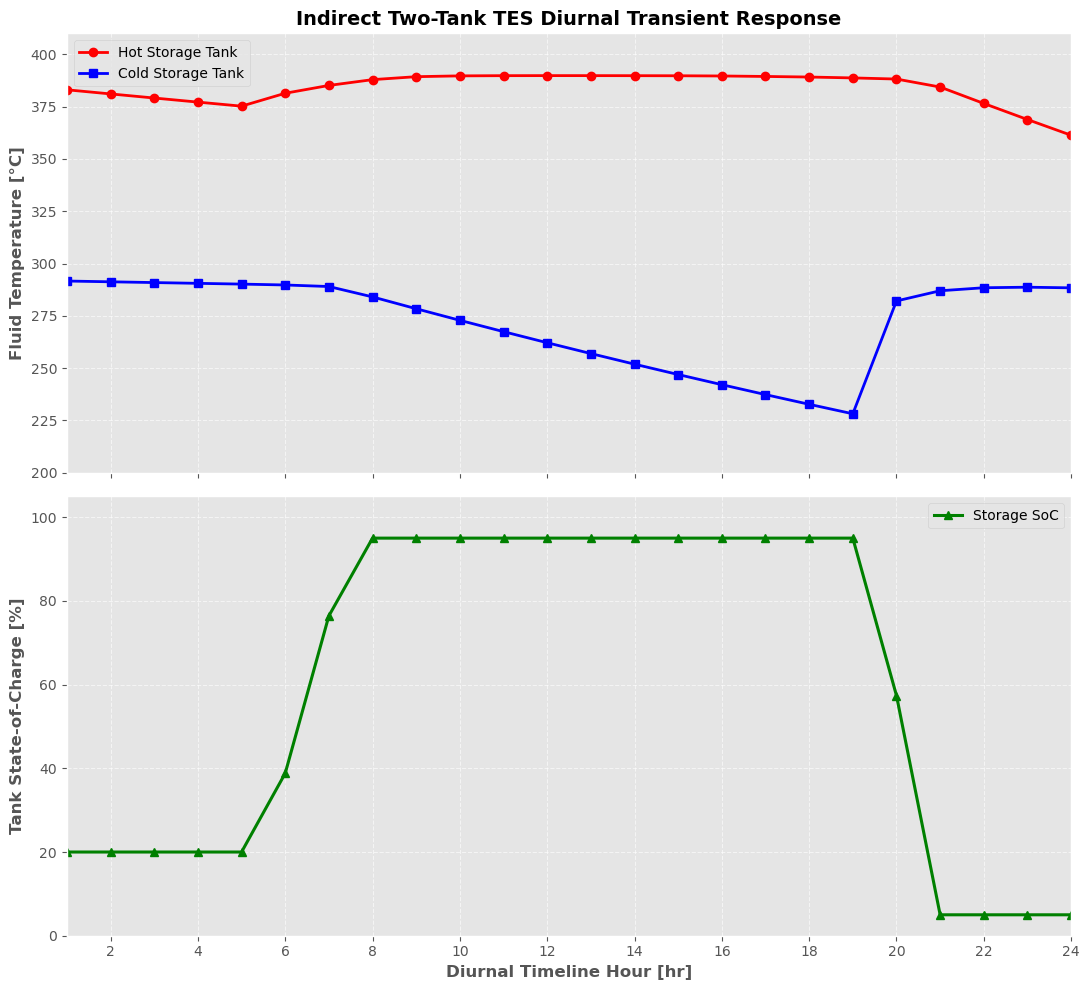

     TES FIELD CONVERGENCE PERFORMANCE SUMMARY    
Working Storage Medium         : Therminol VP-1 Liquid HTF
Total System Fluid Inventory   : 47850.00 kg
--------------------------------------------------
Absolute Peak State-of-Charge  : 95.00 % (at Hour 8:00)
Hot Storage Tank Max Core Temp : 389.79 °C
Cold Storage Tank Min Core Temp: 228.19 °C
--------------------------------------------------
Maximum Charging Mass Flow Rate: 26.50 kg/s
Maximum Discharge Flow Rate    : 10.00 kg/s


In [15]:
# =============================================================================
# 4. VISUALIZATIONS & CONSOLE PRINTER REGISTRY
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Plot 1: Tank Temperature Tracks (Rescaled to capture full cold tank descent)
ax1.plot(df_tes_results['Hour'], df_tes_results['T_hot [°C]'], 'r-o', linewidth=2.0, label='Hot Storage Tank')
ax1.plot(df_tes_results['Hour'], df_tes_results['T_cold [°C]'], 'b-s', linewidth=2.0, label='Cold Storage Tank')
ax1.set_ylabel('Fluid Temperature [°C]', fontweight='bold', fontsize=12)
ax1.set_title('Indirect Two-Tank TES Diurnal Transient Response', fontweight='bold', fontsize=14)
ax1.set_ylim([200, 410])  # Lowered from 250 to 200 to reveal full cold fluid trajectory
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Storage Inventory Profile (State of Charge Bounded between 0 - 100%)
ax2.plot(df_tes_results['Hour'], df_tes_results['SoC [%]'], 'g-^', linewidth=2.2, label='Storage SoC')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('Tank State-of-Charge [%]', fontweight='bold', fontsize=12)
ax2.set_xlim([1, 24]); ax2.set_xticks(range(2, 25, 2))
ax2.set_ylim([0, 105])  # Adjusted to sit flush with physical parameters
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# ---------- Extract Technical Performance Metrics ----------
peak_charge_row = df_tes_results.loc[df_tes_results['SoC [%]'].idxmax()]
net_thermal_oil_mass = V_tank_max * rho_oil

# =============================================================================
# 5. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     TES FIELD CONVERGENCE PERFORMANCE SUMMARY    ")
print(f"==================================================")
print(f"Working Storage Medium         : Therminol VP-1 Liquid HTF")
print(f"Total System Fluid Inventory   : {net_thermal_oil_mass:.2f} kg")
print(f"--------------------------------------------------")
print(f"Absolute Peak State-of-Charge  : {peak_charge_row['SoC [%]']:.2f} % (at Hour {int(peak_charge_row['Hour'])}:00)")
print(f"Hot Storage Tank Max Core Temp : {df_tes_results['T_hot [°C]'].max():.2f} °C")
print(f"Cold Storage Tank Min Core Temp: {df_tes_results['T_cold [°C]'].min():.2f} °C")
print(f"--------------------------------------------------")
print(f"Maximum Charging Mass Flow Rate: {df_tes_results['M_dot [kg/s]'].max():.2f} kg/s")
print(f"Maximum Discharge Flow Rate    : {abs(df_tes_results['M_dot [kg/s]'].min()):.2f} kg/s")
print(f"==================================================")